In [ ]:
#input data
import numpy as np
from pathlib import Path
from scipy import constants

n1 = 1.52              #material ref. index
n0 = 1                  #enviroment ref. index

frequency = 180                  #GHz
wavelenght = constants.c *1000 / (frequency*(10**9))  #mm

# Update matrix size to 128x128 for the phase mask
matrix_size = (128, 128)  # px

# Update matrix center for the new size
matrix_center = (matrix_size[0] / 2, matrix_size[1] / 2)  # Center of the matrix

# Ensure lens diameter and other parameters are adjusted accordingly
lens_diameter = 150  # mm (unchanged, but ensure compatibility with new matrix size)

# Update sampling to match the new resolution
sampling = 800  # um (unchanged, but ensure compatibility with new matrix size)

# Adjust other parameters if necessary to ensure compatibility with the new resolution

kolowa =  True       #False if square aperture  
podstawa = 1                     #mm 

ramka_width_mm = 5
ramka_width_px = ramka_width_mm*sampling/1000
ramka_h_mm = 10
ramka_h_px = ramka_h_mm*sampling/1000
holder_h_px = ramka_h_px
holder_lenght_mm = 0
holder_width_mm = 20
holder_lenght_px = holder_lenght_mm*sampling/1000
holder_width_px = holder_width_mm*sampling/1000

# Update the path to the BMP file to match the provided path
path = Path("/workspace/CD2NN-for-THz/cd2nn_working_fft/best_doe_masks/doe.bmp")

h_max = wavelenght/(n1-n0)         #mm
print(f'h_max = {h_max}')

h_max = 3.202910876068376


None
None
(10, 10)


[ WARN:0@647.174] global loadsave.cpp:268 findDecoder imread_('/workspace/CD2NN-for-THz/cd2nn_working_fft/best_doe_masks/*.bmp'): can't open/read file: check file path/integrity


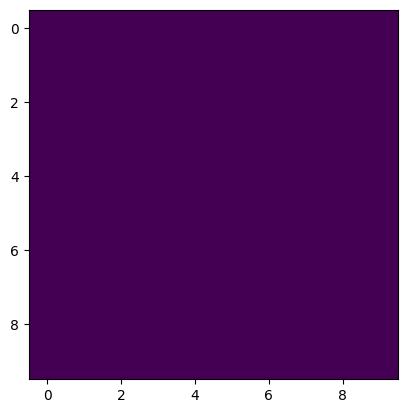

In [39]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

obrazek = cv2.imread(f'{path}', cv2.IMREAD_GRAYSCALE)

print(np.max(obrazek))
print(np.min(obrazek))



auxs_size = int(ramka_width_px + holder_lenght_px + 1)
# cut off lens from the middle of the matrix - NN zakomatowac linijke nizej
# obrazek = obrazek[          #zakomentuj jak kwadratowa apertura
#     int(matrix_center[0]-(lens_diameter/sampling*1000/2)):
#         int(matrix_center[0]+(lens_diameter/sampling*1000/2)), 
#     int(matrix_center[0]-(lens_diameter/sampling*1000/2)+1):          #x position
#         int(matrix_center[0]+(lens_diameter/sampling*1000/2)+1)       #x position
#         ]

obrazek = cv2.copyMakeBorder(obrazek, auxs_size, auxs_size, auxs_size, auxs_size, cv2.BORDER_CONSTANT)

obrazek = obrazek.astype(int)
matrix_size = ((np.size(obrazek[0]), np.size(obrazek[1])))
print(matrix_size)
plt.imshow(obrazek)





(10, 10)
(10, 10)


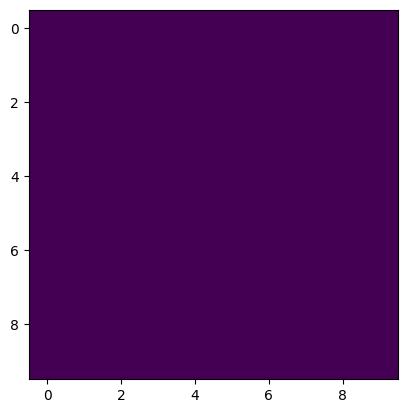

In [40]:
from sklearn.metrics import euclidean_distances


if kolowa:
    metric = lambda x, y: ((x[0] - y[0])** 2 + (x[1] - y[1])**2)**(1/2)
else:
    metric = lambda x, y: max(abs(x[0] - y[0]), abs(x[1] - y[1]))
print(matrix_size)
print(obrazek.shape)
for i in range(matrix_size[0]):
    for j in range(matrix_size[1]):
        central_point = (matrix_size[0]/2,  matrix_size[1]/2)
        considered_point = (i, j)
        distance = metric(central_point, considered_point)
        if  i>matrix_size[0]/2+lens_diameter/sampling*1000/2+ramka_width_px-4 and i<matrix_size[0]/2+lens_diameter/sampling*1000/2+ramka_width_px-4+holder_lenght_px and j>matrix_size[0]/2-holder_width_px/2 and j<matrix_size[0]/2+holder_width_px/2:
            obrazek[i, j] = holder_h_px*255/h_max - podstawa*255/h_max
        else:
            if distance  > lens_diameter/sampling*1000/2+ramka_width_px:          
                obrazek[i, j] = -200
            else:
                if distance <= lens_diameter/sampling*1000/2+ramka_width_px and distance > lens_diameter/sampling*1000/2:
                    obrazek[i, j] = ramka_h_px*255/h_max - podstawa*255/h_max
                else:
                    obrazek[i, j] = obrazek[i, j]
                
            
plt.imshow(obrazek)
plt.show()

In [41]:
# Surface of matrix_size

import numpy as np
from stl import mesh

# Define the 8 vertices of the cube

vertices = np.zeros((matrix_size[1], matrix_size[0], 3))
facesNp_collect = []


for x in range(0, matrix_size[0]):
    for y in range(0, matrix_size[1]):
        pixel_value = obrazek[y][x]
        if pixel_value >= 0:
            z = pixel_value/255*h_max + podstawa
            faces = []

            vertices = np.array([\
                [(y)*sampling/1000, (x)*sampling/1000, 0],
                [(y+1)*sampling/1000, (x)*sampling/1000, 0],
                [(y+1)*sampling/1000, (x+1)*sampling/1000, 0],
                [(y)*sampling/1000, (x+1)*sampling/1000, 0],
                [(y)*sampling/1000, (x)*sampling/1000, z],
                [(y+1)*sampling/1000, (x)*sampling/1000, z],
                [(y+1)*sampling/1000, (x+1)*sampling/1000, z],
                [(y)*sampling/1000, (x+1)*sampling/1000, z]])

            # Define the 12 triangles composing the cube
            face1 = np.array([0,3,1])
            face2 = np.array([1,3,2])
            face3 = np.array([0,4,7])
            face4 = np.array([0,7,3])
            face5 = np.array([4,5,6])
            face6 = np.array([4,6,7])
            face7 = np.array([5,1,2])
            face8 = np.array([5,2,6])
            face9 = np.array([2,3,6])
            face10 = np.array([3,7,6])
            face11 = np.array([0,1,5])
            face12 = np.array([0,5,4])

            # Collect faces
            faces.append(face1) 
            faces.append(face2)
            faces.append(face3)
            faces.append(face4)
            faces.append(face5)
            faces.append(face6)
            faces.append(face7)
            faces.append(face8)
            faces.append(face9)
            faces.append(face10)
            faces.append(face11)
            faces.append(face12)

            facesNp = np.stack(faces)
            facesNp2 = np.zeros(shape = (*facesNp.shape, 3))

            for l in range(3):
                facesNp2[:, l ] = vertices[facesNp[:, l]]

            facesNp_collect.append(facesNp2)
    
# Create the mesh
facesNp2 = np.concatenate(facesNp_collect)

model = mesh.Mesh(np.zeros(facesNp2.shape[0], dtype=mesh.Mesh.dtype))
model.vectors = facesNp2

model.save(f'{path.parent}/{path.stem}.stl')